In [1]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

# Leave Microscope Out

In [2]:
df = pd.read_csv('/scr/yren/mndino_figures/figure5_LMO.csv')

In [3]:
df

,Precision,Recall,F1,Model,Subset
0,0.63,0.61,0.62,mnDINO Hold Out,BBBC039
1,0.92,0.81,0.86,mnDINO Hold Out,mnDINO_data_01
2,0.75,0.94,0.84,mnDINO Hold Out,mnDINO_data_02
3,0.83,0.73,0.78,mnDINO Hold Out,MNFinder Data
4,0.74,0.62,0.67,mnDINO,BBBC039
5,0.89,0.92,0.90,mnDINO,mnDINO_data_01
6,0.83,0.88,0.85,mnDINO,mnDINO_data_02
7,0.77,0.75,0.76,mnDINO,MNFinder Data


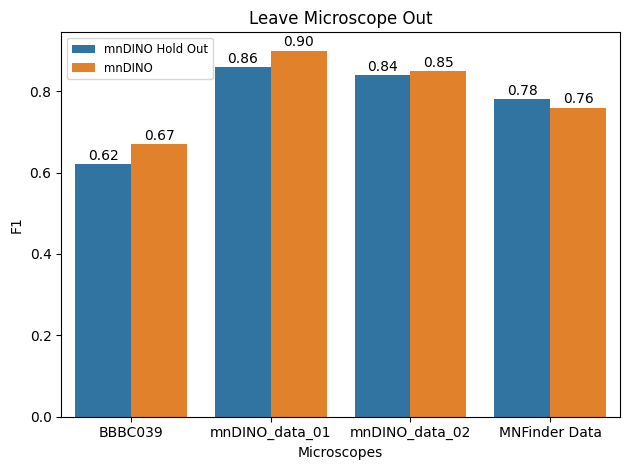

In [4]:
ax = sb.barplot(
    data=df,
    x='Subset',
    y='F1',
    hue='Model'
)
plt.xlabel('Microscopes')
plt.title('Leave Microscope Out')
plt.tight_layout()
plt.legend(loc='upper left', fontsize='small')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=1)
plt.show()

In [5]:
palette = dict(zip(df['Model'].unique(), sb.color_palette()))
palette

{'mnDINO Hold Out': (0.12156862745098039,
  0.4666666666666667,
  0.7058823529411765),
 'mnDINO': (1.0, 0.4980392156862745, 0.054901960784313725)}

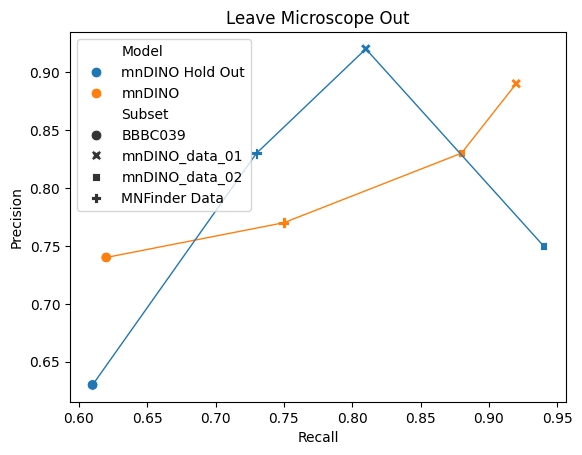

In [6]:
plot1 = sb.scatterplot(
    data=df,
    x='Recall',
    y='Precision',
    hue='Model',
    style='Subset',
    s=60,
)
palette = dict(zip(df['Model'].unique(), sb.color_palette()))
for model, group_data in df.groupby('Model'):
    group_data = group_data.sort_values('Recall')
    plt.plot(
        group_data['Recall'],
        group_data['Precision'],
        color=palette[model],
        marker=None,
        linestyle='-',
        linewidth=1
    )
    
plot1.set_title('Leave Microscope Out')
plt.show()

# Leave Cell-Line Out

In [7]:
df2 = pd.read_csv('/scr/yren/mndino_figures/figure5_LCO.csv')
df2.head()

,Precision,Recall,F1,Model,Cell-line
0,0.55,0.62,0.59,mnDINO Hold Out,U2OS
1,0.72,0.87,0.79,mnDINO Hold Out,HeLa
2,0.85,0.79,0.82,mnDINO Hold Out,RPE1
3,0.74,0.62,0.67,mnDINO,U2OS
4,0.82,0.91,0.86,mnDINO,HeLa


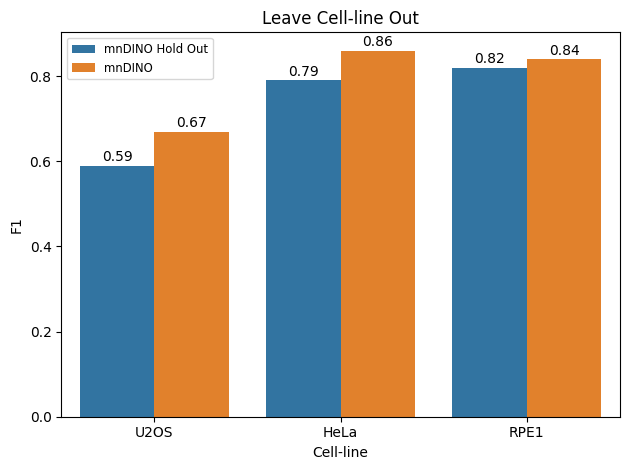

In [8]:
ax = sb.barplot(
    data=df2,
    x='Cell-line',
    y='F1',
    hue='Model'
)
plt.title('Leave Cell-line Out')
plt.tight_layout()
plt.legend(loc='upper left', fontsize='small')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=1)
plt.show()

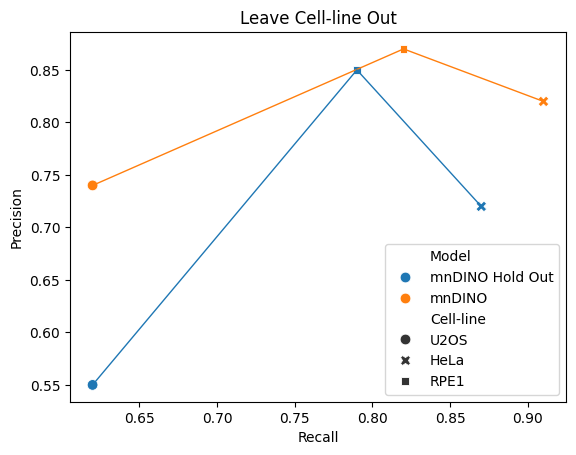

In [9]:
plot2 = sb.scatterplot(
    data=df2,
    x='Recall',
    y='Precision',
    hue='Model',
    style='Cell-line',
    s=60
)

palette = dict(zip(df2['Model'].unique(), sb.color_palette()))
for model, group_data in df2.groupby('Model'):
    group_data = group_data.sort_values('Recall')
    plt.plot(
        group_data['Recall'],
        group_data['Precision'],
        color=palette[model],
        marker=None,
        linestyle='-',
        linewidth=1
    )

plot2.set_title('Leave Cell-line Out')
plt.show()

# Computational Cost

In [9]:
round(0.34, 1)

0.3

In [12]:
cost = pd.read_csv('/hdd/jcaicedo/projects/micronuclei_detection/Train_and_Eval/mndino_data/figures/mndino_figures/computational_cost.csv')
cost['Inference Time'] = cost['Inference Time'].apply(lambda x: int(x) if x > 1 else round(x, 1))
cost.head()

,Subset,Inference Time,F1,Step
0,BBBC039,8.0,0.665779,16
1,mnDINO_data_01,527.0,0.906966,16
2,mnDINO_data_02,441.0,0.881833,16
3,MNFinder Data,17.0,0.813847,16
4,BBBC039,2.0,0.666509,32


In [13]:
cost.Step.unique()

array([ 16,  32,  64, 128, 256])

In [20]:
import numpy as np

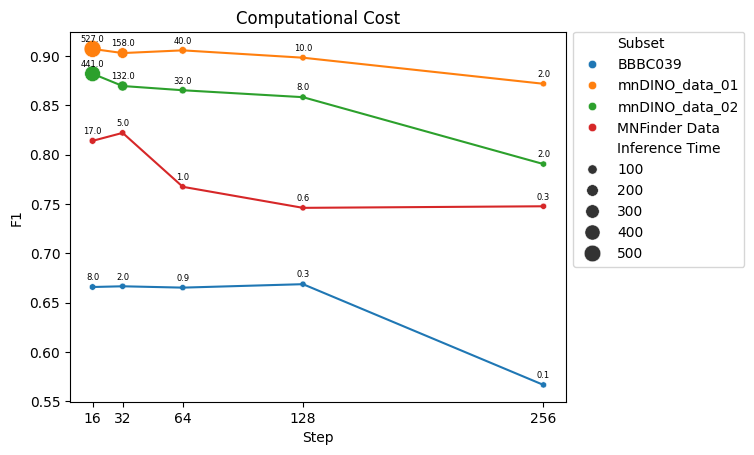

In [28]:
plot_cost = sb.scatterplot(
    x=cost['Step'],
    y=cost['F1'],
    size=cost['Inference Time'],
    hue=cost['Subset'],
    sizes=(20, 150)
)

palette = dict(zip(cost['Subset'].unique(), sb.color_palette()))
for subset, group_data in cost.groupby('Subset'):
    group_data = group_data.sort_values('Step')  # sort so lines look clean
    plt.plot(
        group_data['Step'],
        group_data['F1'],
        color=palette[subset],
        linestyle='-'
    )

text_offset = 0.005
for _, row in cost.iterrows():
    plt.text(
        row['Step'],
        row['F1'] + text_offset,
        f"{row['Inference Time']}",
        fontsize=6,
        ha='center',
        va='bottom'
    )
    
plt.xticks(cost.Step.unique())
plt.legend(bbox_to_anchor=(1, 1.02), loc='upper left')
plt.title('Computational Cost')
plt.show()

In [13]:
df_time = pd.read_csv('/scr/yren/mndino_figures/figure5_inference_time.csv')
df_time.head()

,Subset,Method,Inference Time
0,BBBC039,mnDINO,0.853484
1,mnDINO_data_01,mnDINO,40.286448
2,mnDINO_data_02,mnDINO,32.974286
3,MNFinder Data,mnDINO,1.741493
4,BBBC039,MNFinder,2.876928


In [14]:
df_time['Inference Time'].to_list()

[0.8534835364,
 40.28644787,
 32.9742864,
 1.741492907,
 2.876928251,
 403.9256777,
 226.4527345,
 8.136475943,
 2.11985541,
 71.0713861,
 58.5566864,
 5.642371893,
 1.061465942,
 4.783279657,
 4.873809695,
 1.473866863]

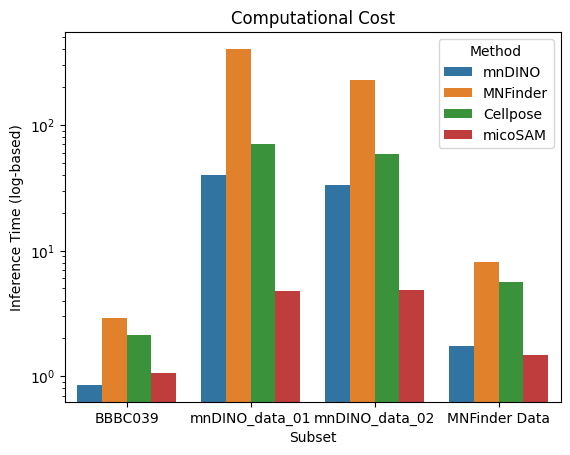

In [15]:
fig, ax1 = plt.subplots()

# Left y-axis with log scale
sb.barplot(
    data=df_time,
    x='Subset',
    y='Inference Time',
    hue='Method',
    ax=ax1
)
ax1.set_yscale('log')
ax1.set_ylabel('Inference Time (log-based)')
ax1.set_title('Computational Cost')
# Right y-axis (non-log)
# ax2 = ax1.twinx()
# ax2.set_ylabel('Inference Time (second)')
# ax2.set_ylim(ax1.get_ylim())  # match limits
# ax2.set_yscale('linear')      # explicitly set linear

plt.show()